# 🛡️ Agent-Based Simulation of Cyber Threat Propagation in a Local Server Network

**Judul:** Agent-Based Simulation of Cyber Threat Propagation in a Local Server Network:  
Studi Kasus Efektivitas Intervensi Patch Management dan User Training terhadap Tingkat Kerentanan

**Metode:** Agent-Based Modeling (ABM)  
**Tools:** Mesa · NetworkX · Pandas · NumPy · Matplotlib · Seaborn

---

## 📌 Latar Belakang

Ancaman siber (cyber threat) merupakan risiko kritis bagi infrastruktur jaringan server lokal di berbagai organisasi. Penyebaran malware, ransomware, dan ancaman siber lainnya menyebar melalui koneksi antar node dalam jaringan — menyerupai dinamika penyebaran penyakit dalam epidemiologi.

Studi ini menggunakan **Agent-Based Modeling (ABM)** untuk mensimulasikan bagaimana ancaman siber menyebar dalam jaringan server lokal, serta mengevaluasi efektivitas dua strategi mitigasi:

1. **Patch Management** — Penerapan pembaruan keamanan (*security patch*) pada server
2. **User Training** — Pelatihan kesadaran keamanan siber bagi pengguna

## 📌 Tujuan Penelitian

1. Memodelkan dinamika penyebaran ancaman siber dalam jaringan lokal menggunakan ABM
2. Mengukur efektivitas Patch Management terhadap pengurangan tingkat kerentanan
3. Mengukur efektivitas User Training dalam mencegah propagasi ancaman siber
4. Membandingkan empat skenario intervensi melalui eksperimen simulasi Monte Carlo

---
## 📦 Sel 1: Import Library

In [3]:
import warnings
warnings.filterwarnings('ignore')

import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from enum import Enum
from tqdm import tqdm
from scipy import stats
import os

from mesa import Agent, Model
from mesa.datacollection import DataCollector

# Custom RandomActivation Scheduler (kompatibel dengan versi Mesa terbaru)
class RandomActivation:
    """Simple random activation scheduler."""
    def __init__(self, model):
        self.model = model
        self.agents = []
        self.time = 0
    
    def add(self, agent):
        self.agents.append(agent)
    
    def remove(self, agent):
        if agent in self.agents:
            self.agents.remove(agent)
    
    def step(self):
        """Shuffle agents and call step on each."""
        shuffled = self.agents.copy()
        random.shuffle(shuffled)
        for agent in shuffled:
            agent.step()
        self.time += 1

# Gaya plot dark mode
plt.rcParams.update({
    'figure.facecolor'  : '#0f1117',
    'axes.facecolor'    : '#1a1d2e',
    'axes.edgecolor'    : '#2d3154',
    'axes.labelcolor'   : '#e0e0e0',
    'xtick.color'       : '#a0a0b0',
    'ytick.color'       : '#a0a0b0',
    'text.color'        : '#e0e0e0',
    'grid.color'        : '#2d3154',
    'grid.linestyle'    : '--',
    'grid.alpha'        : 0.5,
    'font.size'         : 11,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
})

PALETTE = {
    'Baseline (Tanpa Intervensi)'   : '#ff4d6d',
    'Patch Management Only'         : '#ffd166',
    'User Training Only'            : '#06d6a0',
    'Combined Intervention'         : '#4cc9f0',
}

print('✅ Semua library berhasil diimport.')

✅ Semua library berhasil diimport.


---
## ⚙️ Sel 2: Parameter Simulasi

In [4]:
# ── Jaringan ─────────────────────────────────────────────────────────────────
N_AGENTS         = 50    # Jumlah node/server
EDGE_PROB        = 0.08  # Probabilitas koneksi antar node (Erdős–Rényi)
INITIAL_INFECTED = 5     # Node yang terinfeksi di awal

# ── Simulasi ──────────────────────────────────────────────────────────────────
N_STEPS          = 200   # Durasi simulasi (langkah waktu)
N_RUNS           = 30    # Percobaan Monte Carlo per skenario
RANDOM_SEED      = 42

# ── Dinamika Penyebaran Ancaman ───────────────────────────────────────────────
BETA             = 0.30  # Infection rate dasar
GAMMA            = 0.05  # Recovery rate (pemulihan alami per step)
EPSILON          = 0.01  # Ancaman latar belakang (serangan eksternal acak)

# ── Parameter Intervensi ──────────────────────────────────────────────────────
ALPHA            = 0.60  # Efektivitas patch (mengurangi vulnerability)
TAU              = 0.50  # Efektivitas training (mengurangi transmisi)
PATCH_THRESHOLD  = 0.70  # Ambang V untuk trigger patch reaktif
TRAINING_INTERVAL = 10  # Interval steps training rutin

print('📋 Parameter Simulasi:')
print(f'   Jumlah server         : {N_AGENTS} node')
print(f'   Topologi jaringan     : Erdős–Rényi Random Graph (p={EDGE_PROB})')
print(f'   Durasi simulasi       : {N_STEPS} langkah waktu')
print(f'   Monte Carlo runs      : {N_RUNS} percobaan / skenario')
print(f'   Infection rate (β)    : {BETA}')
print(f'   Recovery rate (γ)     : {GAMMA}')
print(f'   Efektivitas patch (α) : {ALPHA}')
print(f'   Efektivitas training  : {TAU}')

📋 Parameter Simulasi:
   Jumlah server         : 50 node
   Topologi jaringan     : Erdős–Rényi Random Graph (p=0.08)
   Durasi simulasi       : 200 langkah waktu
   Monte Carlo runs      : 30 percobaan / skenario
   Infection rate (β)    : 0.3
   Recovery rate (γ)     : 0.05
   Efektivitas patch (α) : 0.6
   Efektivitas training  : 0.5


---
## 🤖 Sel 3: State Machine Agen

Setiap node server memiliki 4 kemungkinan kondisi (state):

| State | Simbol | Deskripsi |
|---|---|---|
| `SUSCEPTIBLE` | S | Rentan — belum terinfeksi, bisa terinfeksi |
| `INFECTED` | I | Terinfeksi — sedang menyebarkan ancaman |
| `PATCHED` | P | Ter-patch — kerentanan dikurangi oleh patch |
| `RECOVERED` | R | Pulih — selamat dari infeksi |

In [5]:
class NodeState(Enum):
    SUSCEPTIBLE = 'S'
    INFECTED    = 'I'
    PATCHED     = 'P'
    RECOVERED   = 'R'

STATE_COLORS = {
    NodeState.SUSCEPTIBLE : '#ffd166',
    NodeState.INFECTED    : '#ff4d6d',
    NodeState.PATCHED     : '#4cc9f0',
    NodeState.RECOVERED   : '#06d6a0',
}

print('✅ State machine terdefinisi.')
print('   Alur: SUSCEPTIBLE → INFECTED → RECOVERED')
print('         SUSCEPTIBLE → PATCHED (jika intervensi patch aktif)')

✅ State machine terdefinisi.
   Alur: SUSCEPTIBLE → INFECTED → RECOVERED
         SUSCEPTIBLE → PATCHED (jika intervensi patch aktif)


---
## 🖥️ Sel 4: Kelas ServerNode (Agen)

### Atribut Setiap Agen

| Atribut | Simbol | Rentang | Keterangan |
|---|---|---|---|
| `vulnerability` | V | [0, 1] | Tingkat kerentanan node |
| `patch_level` | PL | [0, 1] | Level patch yang diterapkan |
| `user_awareness` | UA | [0, 1] | Tingkat kesadaran keamanan pengguna |

### Formula Matematika

**Update Vulnerability per langkah:**
$$V(t+1) = V(t) \times (1 - \alpha \cdot PL) \times (1 - \tau \cdot UA) + \varepsilon$$

**Probabilitas Infeksi dari Tetangga:**
$$P_{infect} = \beta \times V(t) \times (1 - UA) \times \frac{n_{infected\_neighbors}}{n_{neighbors}}$$

In [13]:
class ServerNode(Agent):
    """
    Agen yang merepresentasikan satu server dalam jaringan lokal.

    Aturan Transisi State:
      SUSCEPTIBLE → INFECTED  : P = β × V × (1 - UA) × (n_inf_neighbors / n_neighbors)
      SUSCEPTIBLE → PATCHED   : Jika intervensi patch aktif
      INFECTED    → RECOVERED : Probabilitas γ per langkah
    """

    def __init__(self, unique_id, model, initial_state=NodeState.SUSCEPTIBLE):
        super().__init__(model)
        self.unique_id = unique_id
        self.state = initial_state

        # Variasi atribut antar agen (heterogen)
        self.vulnerability  = self.random.uniform(0.4, 0.9)  # V: kerentanan awal
        self.patch_level    = self.random.uniform(0.0, 0.2)  # PL: patch awal minimal
        self.user_awareness = self.random.uniform(0.1, 0.4)  # UA: kesadaran awal rendah

    # ── Update Vulnerability ──────────────────────────────────────────────────
    def update_vulnerability(self):
        """
        Formula: V(t+1) = V(t) × (1 - α·PL) × (1 - τ·UA) + ε
        Patch dan training mengurangi kerentanan secara berlapis.
        ε mensimulasikan kemunculan ancaman baru secara latar belakang.
        """
        self.vulnerability = (
            self.vulnerability
            * (1 - self.model.alpha * self.patch_level)
            * (1 - self.model.tau   * self.user_awareness)
            + self.model.epsilon
        )
        self.vulnerability = float(np.clip(self.vulnerability, 0.0, 1.0))

    # ── Logika Infeksi ────────────────────────────────────────────────────────
    def try_infect(self):
        """Cek apakah node bisa terinfeksi dari tetangga atau ancaman eksternal."""
        if self.state != NodeState.SUSCEPTIBLE:
            return

        neighbors = list(self.model.graph.neighbors(self.unique_id))

        if not neighbors:
            # Tanpa tetangga: hanya ancaman eksternal
            if self.random.random() < self.model.epsilon * self.vulnerability:
                self.state = NodeState.INFECTED
            return

        infected_neighbors = [
            n for n in neighbors
            if self.model.agents_dict[n].state == NodeState.INFECTED
        ]

        if not infected_neighbors:
            # Tidak ada tetangga terinfeksi: ancaman eksternal kecil
            if self.random.random() < self.model.epsilon * self.vulnerability:
                self.state = NodeState.INFECTED
            return

        # Probabilitas infeksi dari tetangga terinfeksi
        prop = len(infected_neighbors) / len(neighbors)
        p_infect = float(np.clip(
            self.model.beta * self.vulnerability * (1 - self.user_awareness) * prop,
            0.0, 1.0
        ))
        if self.random.random() < p_infect:
            self.state = NodeState.INFECTED

    # ── Logika Pemulihan ──────────────────────────────────────────────────────
    def try_recover(self):
        """Node terinfeksi bisa pulih secara alami dengan probabilitas γ."""
        if self.state == NodeState.INFECTED:
            if self.random.random() < self.model.gamma:
                self.state = NodeState.RECOVERED
                # Pemulihan sedikit menurunkan kerentanan (imun parsial)
                self.vulnerability = max(0.0, self.vulnerability - 0.08)

    # ── Logika Patch ─────────────────────────────────────────────────────────
    def apply_patch(self):
        """Terapkan patch: ubah state ke PATCHED dan naikkan patch_level."""
        if self.state in [NodeState.SUSCEPTIBLE, NodeState.RECOVERED]:
            self.state = NodeState.PATCHED
            self.patch_level = min(1.0, self.patch_level + 0.55)

    # ── Logika Training ───────────────────────────────────────────────────────
    def apply_training(self):
        """Tingkatkan user_awareness melalui sesi pelatihan."""
        self.user_awareness = min(1.0, self.user_awareness + 0.10)

    # ── Step Utama ────────────────────────────────────────────────────────────
    def step(self):
        """Satu langkah waktu: update vulnerability → cek infeksi → cek pemulihan."""
        self.update_vulnerability()
        self.try_infect()
        self.try_recover()

print('✅ Kelas ServerNode terdefinisi.')
print('   Atribut  : state | vulnerability | patch_level | user_awareness')
print('   Metode   : try_infect() | try_recover() | apply_patch() | apply_training()')

✅ Kelas ServerNode terdefinisi.
   Atribut  : state | vulnerability | patch_level | user_awareness
   Metode   : try_infect() | try_recover() | apply_patch() | apply_training()


---
## 🌐 Sel 5: Kelas CyberThreatModel (Model)

### Topologi Jaringan: Erdős–Rényi Random Graph

Setiap pasangan node terhubung secara acak dengan probabilitas `p = 0.08`. Model ini sederhana namun realistis untuk jaringan flat (datar) dalam lingkungan kantor/lab.

In [7]:
class CyberThreatModel(Model):
    """
    Model ABM penyebaran ancaman siber pada jaringan server lokal.
    Menggunakan topologi Erdős–Rényi Random Graph.
    """

    def __init__(
        self,
        n_agents          = N_AGENTS,
        initial_infected  = INITIAL_INFECTED,
        beta              = BETA,
        gamma             = GAMMA,
        epsilon           = EPSILON,
        alpha             = ALPHA,
        tau               = TAU,
        use_patch         = False,
        use_training      = False,
        patch_proactive   = False,
        training_interval = TRAINING_INTERVAL,
        patch_threshold   = PATCH_THRESHOLD,
        seed              = None,
    ):
        super().__init__()
        if seed is not None:
            self.random.seed(seed)
            np.random.seed(seed)

        # Simpan parameter
        self.n_agents          = n_agents
        self.beta              = beta
        self.gamma             = gamma
        self.epsilon           = epsilon
        self.alpha             = alpha
        self.tau               = tau
        self.use_patch         = use_patch
        self.use_training      = use_training
        self.patch_proactive   = patch_proactive
        self.training_interval = training_interval
        self.patch_threshold   = patch_threshold

        # Buat graf Erdős–Rényi (Random Graph)
        self.graph    = nx.erdos_renyi_graph(n=n_agents, p=EDGE_PROB, seed=seed)
        self.schedule = RandomActivation(self)

        # Tentukan node terinfeksi di awal
        initial_infected_ids = set(self.random.sample(range(n_agents), initial_infected))

        # Buat dan daftarkan semua agen
        self.agents_dict = {}
        for node_id in range(n_agents):
            init_state = (
                NodeState.INFECTED
                if node_id in initial_infected_ids
                else NodeState.SUSCEPTIBLE
            )
            agent = ServerNode(node_id, self, initial_state=init_state)
            self.schedule.add(agent)
            self.agents_dict[node_id] = agent

        # Kolektor data — direkam setiap langkah
        self.datacollector = DataCollector(
            model_reporters={
                'n_susceptible'     : lambda m: sum(1 for a in m.agents_dict.values() if a.state == NodeState.SUSCEPTIBLE),
                'n_infected'        : lambda m: sum(1 for a in m.agents_dict.values() if a.state == NodeState.INFECTED),
                'n_patched'         : lambda m: sum(1 for a in m.agents_dict.values() if a.state == NodeState.PATCHED),
                'n_recovered'       : lambda m: sum(1 for a in m.agents_dict.values() if a.state == NodeState.RECOVERED),
                'avg_vulnerability' : lambda m: float(np.mean([a.vulnerability  for a in m.agents_dict.values()])),
                'avg_user_awareness': lambda m: float(np.mean([a.user_awareness for a in m.agents_dict.values()])),
            }
        )

    # ── Intervensi Patch Management ────────────────────────────────────────────
    def apply_patch_intervention(self):
        """
        Patch Management:
          - Proaktif : Patch semua node susceptible/recovered
          - Reaktif  : Patch hanya node dengan V > threshold
        """
        if not self.use_patch:
            return
        for agent in self.agents_dict.values():
            if self.patch_proactive:
                if agent.state in [NodeState.SUSCEPTIBLE, NodeState.RECOVERED]:
                    agent.apply_patch()
            else:
                if (agent.state in [NodeState.SUSCEPTIBLE, NodeState.RECOVERED]
                        and agent.vulnerability > self.patch_threshold):
                    agent.apply_patch()

    # ── Intervensi User Training ───────────────────────────────────────────────
    def apply_training_intervention(self):
        """
        User Training dilakukan rutin setiap training_interval langkah.
        Meningkatkan user_awareness semua agen.
        """
        if not self.use_training:
            return
        t = self.schedule.time
        if t > 0 and t % self.training_interval == 0:
            for agent in self.agents_dict.values():
                agent.apply_training()

    # ── Langkah Model ─────────────────────────────────────────────────────────
    def step(self):
        """Satu langkah simulasi: kumpulkan data → terapkan intervensi → update agen."""
        self.datacollector.collect(self)
        self.apply_patch_intervention()
        self.apply_training_intervention()
        self.schedule.step()

print('✅ Kelas CyberThreatModel terdefinisi.')
print('   Topologi    : Erdős–Rényi Random Graph')
print('   Intervensi  : Patch Management (proaktif/reaktif) & User Training (rutin)')

✅ Kelas CyberThreatModel terdefinisi.
   Topologi    : Erdős–Rényi Random Graph
   Intervensi  : Patch Management (proaktif/reaktif) & User Training (rutin)


---
## 🎲 Sel 6: Fungsi Runner Monte Carlo

In [8]:
def run_scenario(scenario_name, n_runs, n_steps, model_kwargs):
    """
    Jalankan satu skenario sebanyak n_runs percobaan Monte Carlo.
    
    Returns:
        df_raw     : DataFrame data mentah per langkah
        df_summary : DataFrame ringkasan statistik per run
    """
    raw_records     = []
    summary_records = []
    RECOVERY_THR    = 0.10  # Infeksi < 10% dianggap jaringan telah pulih

    for run_id in tqdm(range(n_runs), desc=f'  {scenario_name}'):
        seed  = RANDOM_SEED + run_id
        model = CyberThreatModel(seed=seed, **model_kwargs)

        peak_infected = 0
        peak_step     = 0
        recovery_step = n_steps  # Default: belum pulih hingga akhir

        for step in range(n_steps):
            model.step()
            data  = model.datacollector.get_model_vars_dataframe().iloc[-1]
            n_inf = int(data['n_infected'])

            if n_inf > peak_infected:
                peak_infected = n_inf
                peak_step     = step + 1

            # Catat langkah pemulihan pertama kali (setelah step ke-10)
            if step > 10 and n_inf / N_AGENTS < RECOVERY_THR and recovery_step == n_steps:
                recovery_step = step + 1

            raw_records.append({
                'skenario'            : scenario_name,
                'run_id'              : run_id + 1,
                'langkah'             : step + 1,
                'n_susceptible'       : int(data['n_susceptible']),
                'n_infected'          : n_inf,
                'n_patched'           : int(data['n_patched']),
                'n_recovered'         : int(data['n_recovered']),
                'rata_vulnerability'  : round(float(data['avg_vulnerability']), 4),
                'rata_user_awareness' : round(float(data['avg_user_awareness']), 4),
            })

        # Data akhir simulasi
        final = model.datacollector.get_model_vars_dataframe().iloc[-1]
        summary_records.append({
            'skenario'              : scenario_name,
            'run_id'                : run_id + 1,
            'puncak_infeksi'        : peak_infected,
            'langkah_puncak'        : peak_step,
            'langkah_pemulihan'     : recovery_step,
            'infeksi_akhir'         : int(final['n_infected']),
            'vulnerability_akhir'   : round(float(final['avg_vulnerability']), 4),
            'user_awareness_akhir'  : round(float(final['avg_user_awareness']), 4),
        })

    df_raw     = pd.DataFrame(raw_records)
    df_summary = pd.DataFrame(summary_records)
    return df_raw, df_summary

print('✅ Fungsi run_scenario() siap.')
print(f'   Total data per skenario: {N_RUNS} runs × {N_STEPS} steps = {N_RUNS * N_STEPS:,} baris')

✅ Fungsi run_scenario() siap.
   Total data per skenario: 30 runs × 200 steps = 6,000 baris


---
## 🧪 Sel 7: Skenario 1 — Baseline (Tanpa Intervensi)

> **Pertanyaan Penelitian:** Apa yang terjadi jika ancaman siber dibiarkan menyebar tanpa intervensi apapun? Seberapa cepat jaringan mencapai titik saturasi infeksi?

**Konfigurasi:** `use_patch = False` · `use_training = False`

In [14]:
print('=' * 60)
print('🔴  SKENARIO 1: Baseline (Tanpa Intervensi)')
print('=' * 60)

s1_kwargs = dict(
    n_agents=N_AGENTS, initial_infected=INITIAL_INFECTED,
    beta=BETA, gamma=GAMMA, epsilon=EPSILON,
    alpha=ALPHA, tau=TAU,
    use_patch=False, use_training=False,
)

df_s1_raw, df_s1_sum = run_scenario(
    scenario_name='Baseline (Tanpa Intervensi)',
    n_runs=N_RUNS, n_steps=N_STEPS, model_kwargs=s1_kwargs,
)

print(f"\n📊 Hasil (rata-rata {N_RUNS} runs):")
print(f"   Puncak infeksi : {df_s1_sum['puncak_infeksi'].mean():.1f} node  "
      f"({df_s1_sum['puncak_infeksi'].mean()/N_AGENTS*100:.1f}%)")
print(f"   Langkah puncak : {df_s1_sum['langkah_puncak'].mean():.0f}")
print(f"   Kerentanan akhir: {df_s1_sum['vulnerability_akhir'].mean():.3f}")

🔴  SKENARIO 1: Baseline (Tanpa Intervensi)


  Baseline (Tanpa Intervensi): 100%|██████████| 30/30 [00:13<00:00,  2.25it/s]


📊 Hasil (rata-rata 30 runs):
   Puncak infeksi : 7.5 node  (14.9%)
   Langkah puncak : 8
   Kerentanan akhir: 0.062


---
## 🧪 Sel 8: Skenario 2 — Patch Management Only

> **Pertanyaan Penelitian:** Apakah patch management reaktif (diterapkan saat kerentanan tinggi) efektif menekan penyebaran ancaman?

**Konfigurasi:** `use_patch = True (reaktif, V > 0.7)` · `use_training = False`

In [15]:
print('=' * 60)
print('🟡  SKENARIO 2: Patch Management Only (Reaktif)')
print('=' * 60)

s2_kwargs = dict(
    n_agents=N_AGENTS, initial_infected=INITIAL_INFECTED,
    beta=BETA, gamma=GAMMA, epsilon=EPSILON,
    alpha=ALPHA, tau=TAU,
    use_patch=True, use_training=False,
    patch_proactive=False, patch_threshold=PATCH_THRESHOLD,
)

df_s2_raw, df_s2_sum = run_scenario(
    scenario_name='Patch Management Only',
    n_runs=N_RUNS, n_steps=N_STEPS, model_kwargs=s2_kwargs,
)

print(f"\n📊 Hasil (rata-rata {N_RUNS} runs):")
print(f"   Puncak infeksi : {df_s2_sum['puncak_infeksi'].mean():.1f} node  "
      f"({df_s2_sum['puncak_infeksi'].mean()/N_AGENTS*100:.1f}%)")
print(f"   Langkah puncak : {df_s2_sum['langkah_puncak'].mean():.0f}")
print(f"   Kerentanan akhir: {df_s2_sum['vulnerability_akhir'].mean():.3f}")

🟡  SKENARIO 2: Patch Management Only (Reaktif)


  Patch Management Only: 100%|██████████| 30/30 [00:12<00:00,  2.34it/s]


📊 Hasil (rata-rata 30 runs):
   Puncak infeksi : 6.4 node  (12.7%)
   Langkah puncak : 5
   Kerentanan akhir: 0.048


---
## 🧪 Sel 9: Skenario 3 — User Training Only

> **Pertanyaan Penelitian:** Apakah pelatihan pengguna rutin (setiap 10 langkah) cukup untuk mencegah penyebaran ancaman tanpa didukung patch?

**Konfigurasi:** `use_patch = False` · `use_training = True (rutin tiap 10 langkah)`

In [16]:
print('=' * 60)
print('🟢  SKENARIO 3: User Training Only (Preventif Rutin)')
print('=' * 60)

s3_kwargs = dict(
    n_agents=N_AGENTS, initial_infected=INITIAL_INFECTED,
    beta=BETA, gamma=GAMMA, epsilon=EPSILON,
    alpha=ALPHA, tau=TAU,
    use_patch=False, use_training=True,
    training_interval=TRAINING_INTERVAL,
)

df_s3_raw, df_s3_sum = run_scenario(
    scenario_name='User Training Only',
    n_runs=N_RUNS, n_steps=N_STEPS, model_kwargs=s3_kwargs,
)

print(f"\n📊 Hasil (rata-rata {N_RUNS} runs):")
print(f"   Puncak infeksi : {df_s3_sum['puncak_infeksi'].mean():.1f} node  "
      f"({df_s3_sum['puncak_infeksi'].mean()/N_AGENTS*100:.1f}%)")
print(f"   Langkah puncak : {df_s3_sum['langkah_puncak'].mean():.0f}")
print(f"   Kerentanan akhir: {df_s3_sum['vulnerability_akhir'].mean():.3f}")

🟢  SKENARIO 3: User Training Only (Preventif Rutin)


  User Training Only: 100%|██████████| 30/30 [00:13<00:00,  2.21it/s]


📊 Hasil (rata-rata 30 runs):
   Puncak infeksi : 7.1 node  (14.3%)
   Langkah puncak : 6
   Kerentanan akhir: 0.019


---
## 🧪 Sel 10: Skenario 4 — Combined Intervention

> **Pertanyaan Penelitian:** Apakah kombinasi Patch Management proaktif + User Training rutin menghasilkan efek sinergistik yang lebih baik?

**Konfigurasi:** `use_patch = True (proaktif)` · `use_training = True (rutin)`

In [17]:
print('=' * 60)
print('🔵  SKENARIO 4: Combined Intervention (Patch + Training)')
print('=' * 60)

s4_kwargs = dict(
    n_agents=N_AGENTS, initial_infected=INITIAL_INFECTED,
    beta=BETA, gamma=GAMMA, epsilon=EPSILON,
    alpha=ALPHA, tau=TAU,
    use_patch=True, use_training=True,
    patch_proactive=True,
    training_interval=TRAINING_INTERVAL,
)

df_s4_raw, df_s4_sum = run_scenario(
    scenario_name='Combined Intervention',
    n_runs=N_RUNS, n_steps=N_STEPS, model_kwargs=s4_kwargs,
)

print(f"\n📊 Hasil (rata-rata {N_RUNS} runs):")
print(f"   Puncak infeksi : {df_s4_sum['puncak_infeksi'].mean():.1f} node  "
      f"({df_s4_sum['puncak_infeksi'].mean()/N_AGENTS*100:.1f}%)")
print(f"   Langkah puncak : {df_s4_sum['langkah_puncak'].mean():.0f}")
print(f"   Kerentanan akhir: {df_s4_sum['vulnerability_akhir'].mean():.3f}")

🔵  SKENARIO 4: Combined Intervention (Patch + Training)


  Combined Intervention: 100%|██████████| 30/30 [00:10<00:00,  2.76it/s]


📊 Hasil (rata-rata 30 runs):
   Puncak infeksi : 5.0 node  (10.0%)
   Langkah puncak : 1
   Kerentanan akhir: 0.014


---
## 💾 Sel 11: Gabungkan Data & Ekspor CSV

In [18]:
# Gabungkan data mentah semua skenario
df_raw_all = pd.concat([df_s1_raw, df_s2_raw, df_s3_raw, df_s4_raw], ignore_index=True)

# Gabungkan ringkasan semua skenario
df_sum_all = pd.concat([df_s1_sum, df_s2_sum, df_s3_sum, df_s4_sum], ignore_index=True)

# Hitung persentase reduksi infeksi vs baseline
baseline_mean_peak = df_s1_sum['puncak_infeksi'].mean()

def hitung_reduksi(row):
    peak_skenario = df_sum_all[
        df_sum_all['skenario'] == row['skenario']
    ]['puncak_infeksi'].mean()
    if baseline_mean_peak > 0:
        return round((baseline_mean_peak - peak_skenario) / baseline_mean_peak * 100, 2)
    return 0.0

df_sum_all['reduksi_infeksi_persen'] = df_sum_all.apply(hitung_reduksi, axis=1)

# ── Ekspor ke CSV ────────────────────────────────────────────────────────────
df_raw_all.to_csv('data_raw_simulasi.csv', index=False, encoding='utf-8-sig')
df_sum_all.to_csv('data_ringkasan_skenario.csv', index=False, encoding='utf-8-sig')

print('💾 File CSV berhasil disimpan!')
print(f'   📄 data_raw_simulasi.csv       → {len(df_raw_all):,} baris · {len(df_raw_all.columns)} kolom')
print(f'   📄 data_ringkasan_skenario.csv  → {len(df_sum_all):,} baris · {len(df_sum_all.columns)} kolom')

print('\n📋 Pratinjau data_raw_simulasi.csv (5 baris):')
display(df_raw_all.head())

print('\n📋 Pratinjau data_ringkasan_skenario.csv (5 baris):')
display(df_sum_all.head())

💾 File CSV berhasil disimpan!
   📄 data_raw_simulasi.csv       → 24,000 baris · 9 kolom
   📄 data_ringkasan_skenario.csv  → 120 baris · 9 kolom

📋 Pratinjau data_raw_simulasi.csv (5 baris):


,skenario,run_id,langkah,n_susceptible,n_infected,n_patched,n_recovered,rata_vulnerability,rata_user_awareness
0,Baseline (Tanpa Intervensi),1,1,45,5,0,0,0.6414,0.2596
1,Baseline (Tanpa Intervensi),1,2,44,6,0,0,0.5331,0.2596
2,Baseline (Tanpa Intervensi),1,3,43,7,0,0,0.4466,0.2596
3,Baseline (Tanpa Intervensi),1,4,42,8,0,0,0.3772,0.2596
4,Baseline (Tanpa Intervensi),1,5,42,8,0,0,0.3213,0.2596



📋 Pratinjau data_ringkasan_skenario.csv (5 baris):


,skenario,run_id,puncak_infeksi,langkah_puncak,langkah_pemulihan,infeksi_akhir,vulnerability_akhir,user_awareness_akhir,reduksi_infeksi_persen
0,Baseline (Tanpa Intervensi),1,8,4,28,0,0.0601,0.2596,0.0
1,Baseline (Tanpa Intervensi),2,6,2,12,0,0.0629,0.2495,0.0
2,Baseline (Tanpa Intervensi),3,10,5,25,0,0.0672,0.2287,0.0
3,Baseline (Tanpa Intervensi),4,8,30,47,0,0.0639,0.2460,0.0
4,Baseline (Tanpa Intervensi),5,6,3,12,0,0.0585,0.2517,0.0


---
## 📊 Sel 12: Tabel Komparatif Antar Skenario

In [19]:
tabel = df_sum_all.groupby('skenario').agg(
    puncak_infeksi_mean   = ('puncak_infeksi',        'mean'),
    puncak_infeksi_std    = ('puncak_infeksi',        'std'),
    langkah_puncak_mean   = ('langkah_puncak',        'mean'),
    langkah_pemulihan_mean= ('langkah_pemulihan',     'mean'),
    vulnerability_akhir   = ('vulnerability_akhir',   'mean'),
    user_awareness_akhir  = ('user_awareness_akhir',  'mean'),
    reduksi_persen        = ('reduksi_infeksi_persen','mean'),
).reset_index()

tabel['puncak_%'] = (tabel['puncak_infeksi_mean'] / N_AGENTS * 100).round(1)

tampil = tabel[['skenario','puncak_%','langkah_puncak_mean',
                'langkah_pemulihan_mean','vulnerability_akhir',
                'user_awareness_akhir','reduksi_persen']].rename(columns={
    'skenario'              : 'Skenario',
    'puncak_%'              : 'Puncak Infeksi (%)',
    'langkah_puncak_mean'   : 'Langkah Puncak',
    'langkah_pemulihan_mean': 'Langkah Pemulihan',
    'vulnerability_akhir'   : 'Kerentanan Akhir',
    'user_awareness_akhir'  : 'Kesadaran Akhir',
    'reduksi_persen'        : 'Reduksi Infeksi (%)',
}).set_index('Skenario')

print('=' * 70)
print(f'📊 TABEL KOMPARATIF (rata-rata {N_RUNS} Monte Carlo Runs per Skenario)')
print('=' * 70)
display(tampil.round(2))

📊 TABEL KOMPARATIF (rata-rata 30 Monte Carlo Runs per Skenario)


,Puncak Infeksi (%),Langkah Puncak,Langkah Pemulihan,Kerentanan Akhir,Kesadaran Akhir,Reduksi Infeksi (%)
Skenario,,,,,,
Baseline (Tanpa Intervensi),14.9,8.30,23.03,0.06,0.25,0.00
Combined Intervention,10.0,1.00,12.57,0.01,1.00,33.04
Patch Management Only,12.7,4.67,16.80,0.05,0.25,14.73
User Training Only,14.3,6.50,19.53,0.02,1.00,4.46


---
## 📈 Sel 13: Visualisasi 1 — Time-Series Infeksi & Kerentanan

Garis tebal = rata-rata 30 run · Area berbayang = rentang ±1 standar deviasi

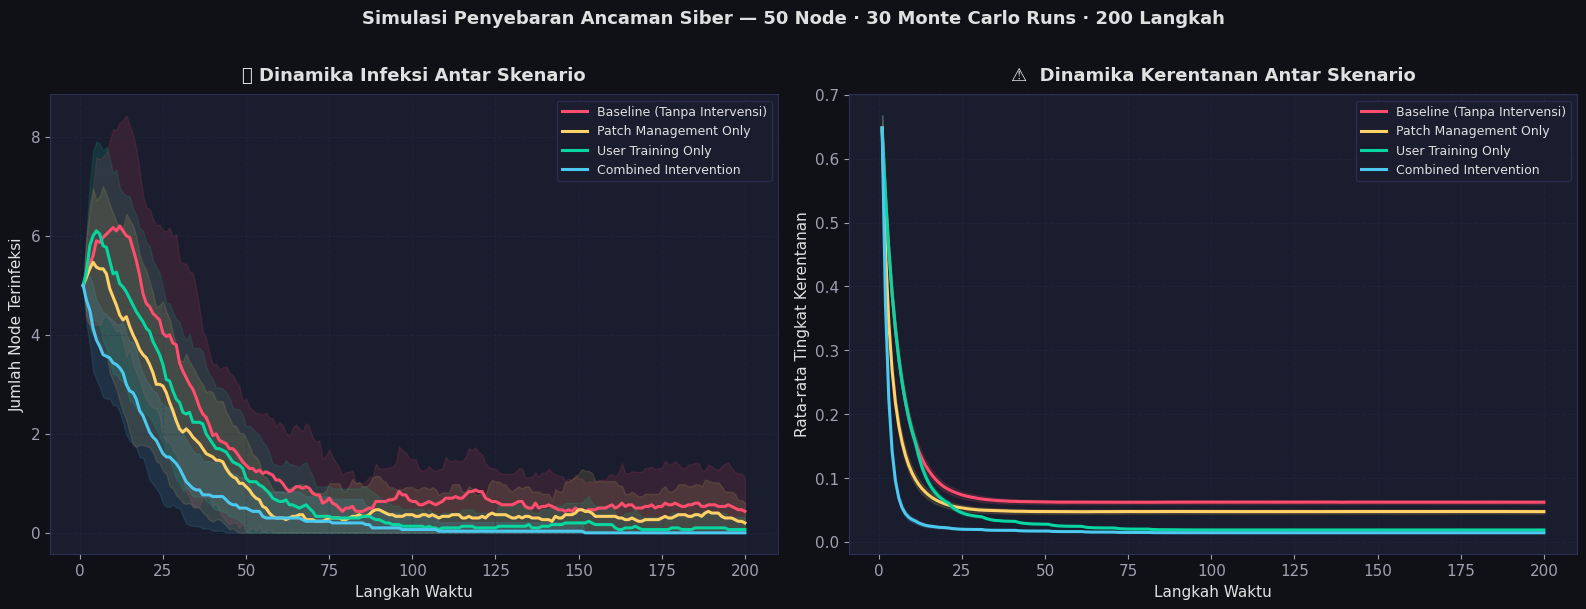

💾 Gambar disimpan: fig_timeseries.png


In [20]:
scenarios = list(PALETTE.keys())
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f1117')

for ax, (metric, ylabel, title) in zip(axes, [
    ('n_infected',          'Jumlah Node Terinfeksi',     '🔴 Dinamika Infeksi Antar Skenario'),
    ('rata_vulnerability',  'Rata-rata Tingkat Kerentanan','⚠️  Dinamika Kerentanan Antar Skenario'),
]):
    for scn in scenarios:
        color = PALETTE[scn]
        df_s  = df_raw_all[df_raw_all['skenario'] == scn]
        grp   = df_s.groupby('langkah')[metric]
        mu, sd = grp.mean(), grp.std()
        ax.plot(mu.index, mu.values, label=scn, color=color, linewidth=2.2)
        ax.fill_between(mu.index, (mu - sd).clip(0), mu + sd, color=color, alpha=0.12)

    ax.set_title(title, pad=10)
    ax.set_xlabel('Langkah Waktu')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9, facecolor='#1a1d2e', edgecolor='#2d3154', labelcolor='#e0e0e0')
    ax.grid(True, alpha=0.3)

plt.suptitle(
    f'Simulasi Penyebaran Ancaman Siber — {N_AGENTS} Node · {N_RUNS} Monte Carlo Runs · {N_STEPS} Langkah',
    fontsize=13, color='#e0e0e0', y=1.01, fontweight='bold'
)
plt.tight_layout()
plt.savefig('fig_timeseries.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('💾 Gambar disimpan: fig_timeseries.png')

---
## 📊 Sel 14: Visualisasi 2 — Distribusi & Efektivitas Intervensi

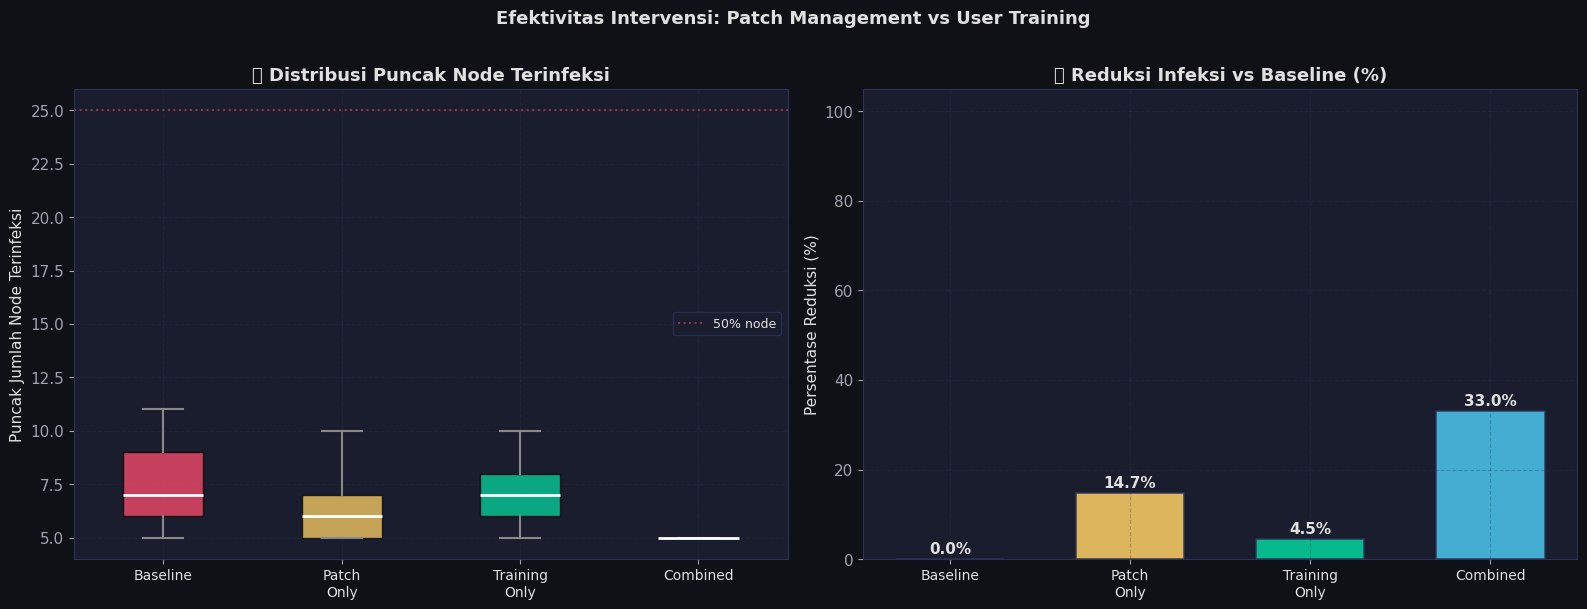

💾 Gambar disimpan: fig_efektivitas.png


In [21]:
palette_list = [PALETTE[s] for s in scenarios]
labels_short  = ['Baseline', 'Patch\nOnly', 'Training\nOnly', 'Combined']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f1117')

# ── Box Plot: Puncak Infeksi ──────────────────────────────────────────────────
ax1 = axes[0]
bp = ax1.boxplot(
    [df_sum_all[df_sum_all['skenario'] == s]['puncak_infeksi'].values for s in scenarios],
    patch_artist=True,
    medianprops  = dict(color='white', linewidth=2),
    whiskerprops = dict(color='#888', linewidth=1.5),
    capprops     = dict(color='#888', linewidth=1.5),
    flierprops   = dict(markerfacecolor='#888', markersize=5, alpha=0.5),
)
for patch, color in zip(bp['boxes'], palette_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax1.set_xticks(range(1, 5))
ax1.set_xticklabels(labels_short, fontsize=10, color='#e0e0e0')
ax1.set_title('📦 Distribusi Puncak Node Terinfeksi')
ax1.set_ylabel('Puncak Jumlah Node Terinfeksi')
ax1.axhline(N_AGENTS * 0.5, color='#ff4d6d', linestyle=':', alpha=0.5, label='50% node')
ax1.legend(fontsize=9, facecolor='#1a1d2e', edgecolor='#2d3154', labelcolor='#e0e0e0')
ax1.grid(True, alpha=0.3)

# ── Bar Chart: Reduksi Infeksi ────────────────────────────────────────────────
ax2 = axes[1]
red_means = [df_sum_all[df_sum_all['skenario'] == s]['reduksi_infeksi_persen'].mean() for s in scenarios]
bars = ax2.bar(labels_short, red_means, color=palette_list,
               edgecolor='#2d3154', linewidth=1.2, alpha=0.85, width=0.6)
for bar, val in zip(bars, red_means):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=11,
             color='#e0e0e0', fontweight='bold')
ax2.set_title('📉 Reduksi Infeksi vs Baseline (%)')
ax2.set_ylabel('Persentase Reduksi (%)')
ax2.set_ylim(0, 105)
ax2.set_xticklabels(labels_short, fontsize=10, color='#e0e0e0')
ax2.grid(True, alpha=0.3)

plt.suptitle('Efektivitas Intervensi: Patch Management vs User Training',
             fontsize=13, color='#e0e0e0', y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_efektivitas.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('💾 Gambar disimpan: fig_efektivitas.png')

---
## 🌈 Sel 15: Visualisasi 3 — Distribusi State Node (Stacked Area)

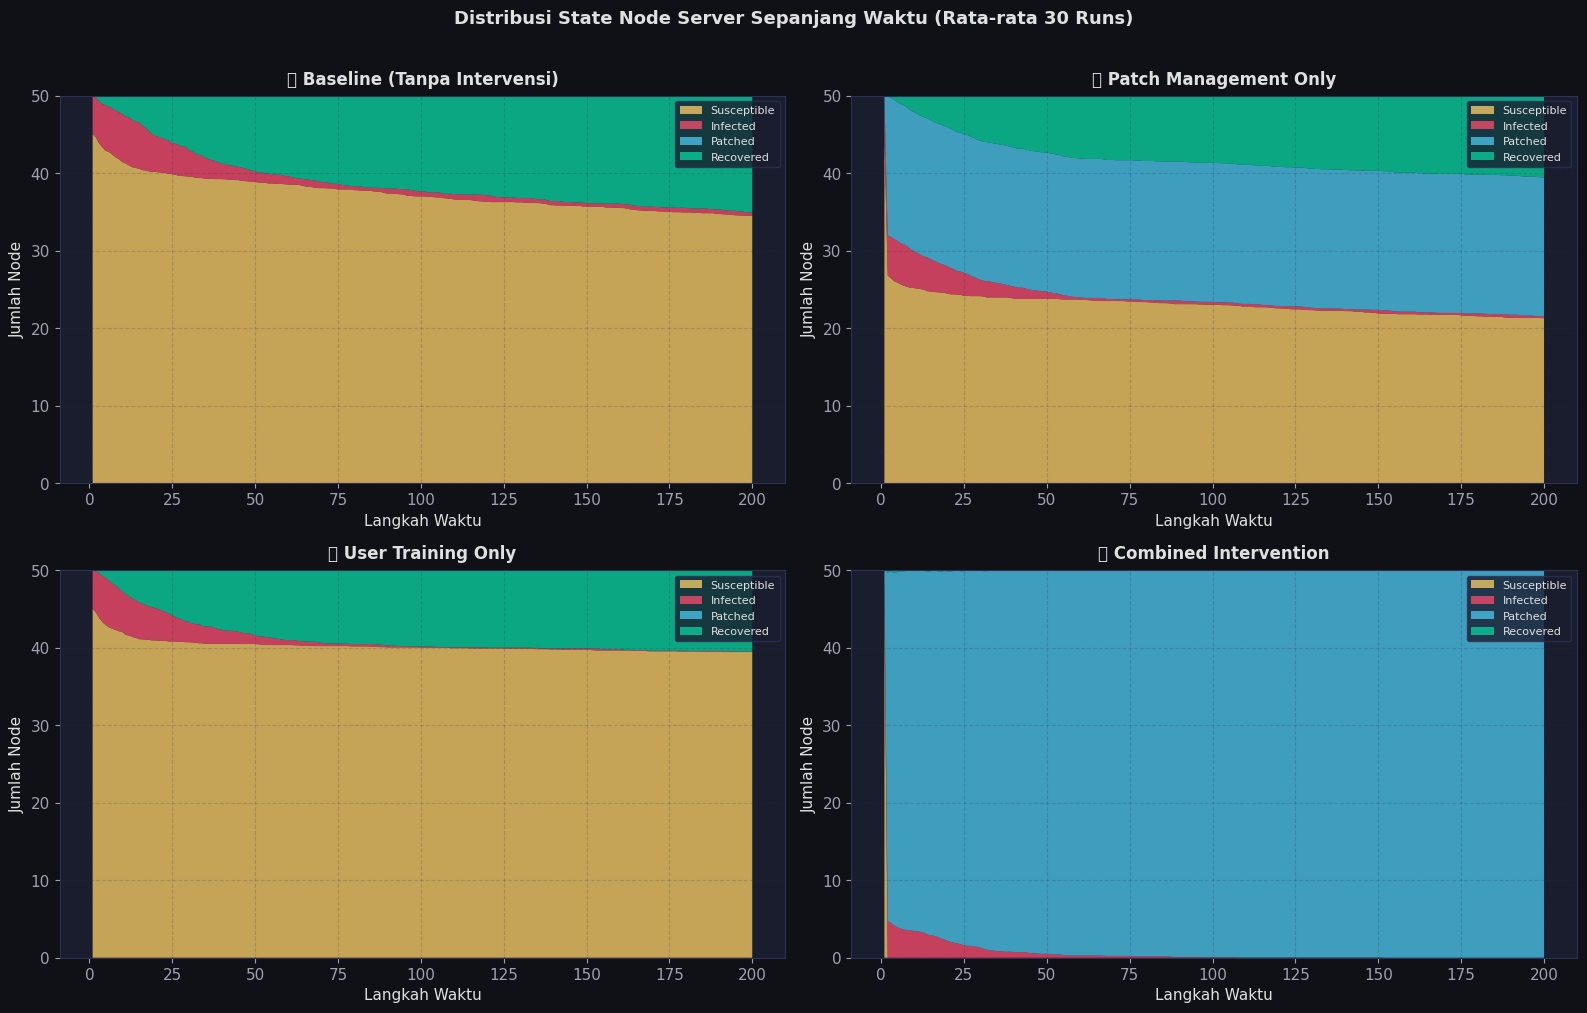

💾 Gambar disimpan: fig_state_distribution.png


In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor('#0f1117')
axes = axes.flatten()

state_cols   = ['n_susceptible','n_infected','n_patched','n_recovered']
state_colors = ['#ffd166','#ff4d6d','#4cc9f0','#06d6a0']
state_labels = ['Susceptible','Infected','Patched','Recovered']
emojis       = ['🔴','🟡','🟢','🔵']

for i, (scn, ax) in enumerate(zip(scenarios, axes)):
    df_s = df_raw_all[df_raw_all['skenario'] == scn]
    grp  = df_s.groupby('langkah')[state_cols].mean()
    ax.stackplot(grp.index, [grp[c].values for c in state_cols],
                 labels=state_labels, colors=state_colors, alpha=0.75)
    ax.set_title(f'{emojis[i]} {scn}', fontsize=12, pad=8)
    ax.set_xlabel('Langkah Waktu')
    ax.set_ylabel('Jumlah Node')
    ax.set_ylim(0, N_AGENTS)
    ax.legend(loc='upper right', fontsize=8,
              facecolor='#1a1d2e', edgecolor='#2d3154', labelcolor='#e0e0e0')
    ax.grid(True, alpha=0.2)

plt.suptitle('Distribusi State Node Server Sepanjang Waktu (Rata-rata 30 Runs)',
             fontsize=13, color='#e0e0e0', y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_state_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('💾 Gambar disimpan: fig_state_distribution.png')

---
## 🕸️ Sel 16: Visualisasi 4 — Snapshot Topologi Jaringan

Perbandingan evolusi jaringan antara skenario Baseline dan Combined Intervention pada 4 titik waktu.

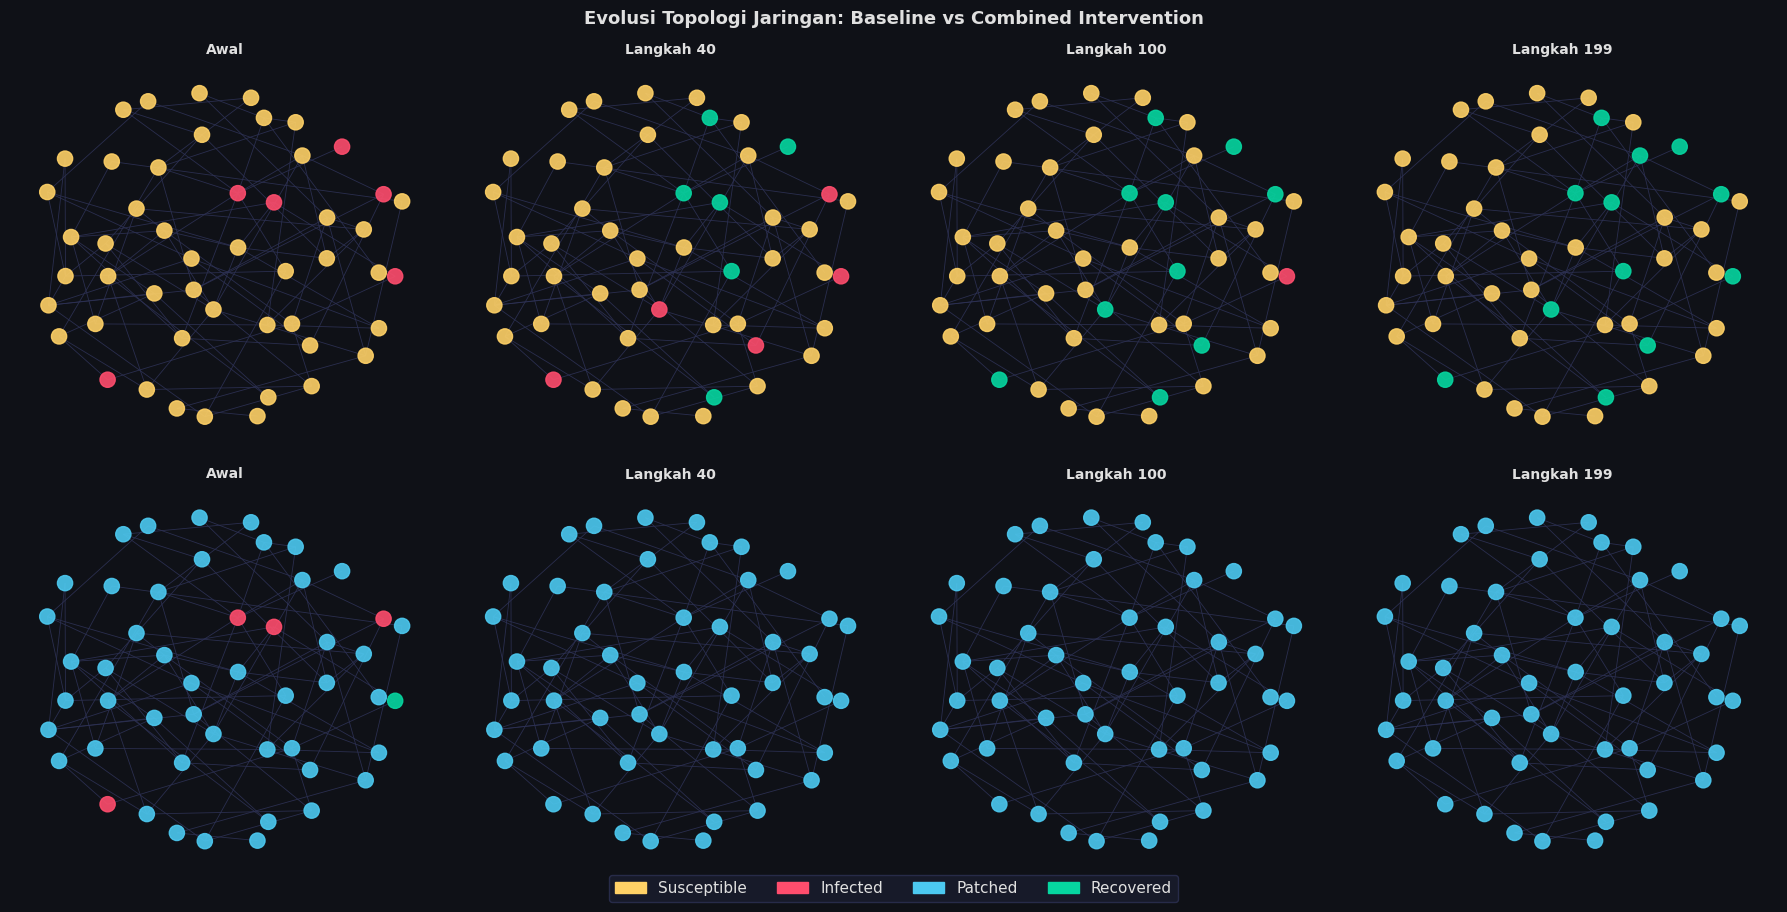

💾 Gambar disimpan: fig_network_snapshot.png


In [23]:
def ambil_snapshot(model_kwargs, steps_to_capture, seed=RANDOM_SEED):
    """Jalankan model dan ambil snapshot state node di setiap step tertentu."""
    model = CyberThreatModel(seed=seed, **model_kwargs)
    snaps = {}
    for step in range(max(steps_to_capture) + 1):
        model.step()
        if step in steps_to_capture:
            snaps[step] = {nid: ag.state for nid, ag in model.agents_dict.items()}
    return model.graph, snaps

tangkap_steps = [0, 40, 100, 199]
snap_scenarios = [
    ('Baseline (Tanpa Intervensi)', s1_kwargs),
    ('Combined Intervention',       s4_kwargs),
]

G_ref = nx.erdos_renyi_graph(n=N_AGENTS, p=EDGE_PROB, seed=RANDOM_SEED)
pos   = nx.spring_layout(G_ref, seed=RANDOM_SEED, k=1.2)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.patch.set_facecolor('#0f1117')

for row, (scn_name, kwargs) in enumerate(snap_scenarios):
    graph, snaps = ambil_snapshot(kwargs, steps_to_capture=tangkap_steps)
    for col, step in enumerate(tangkap_steps):
        ax = axes[row][col]
        state_map   = snaps[step]
        node_colors = [STATE_COLORS[state_map[n]] for n in range(N_AGENTS)]
        nx.draw_networkx(
            graph, pos=pos, ax=ax,
            node_color=node_colors, node_size=120,
            edge_color='#2d3154', with_labels=False, alpha=0.9, width=0.6
        )
        ax.set_facecolor('#1a1d2e')
        label = 'Awal' if step == 0 else f'Langkah {step}'
        ax.set_title(label, fontsize=10, color='#e0e0e0', pad=4)
        ax.axis('off')

for row, (scn_name, _) in enumerate(snap_scenarios):
    axes[row][0].set_ylabel(scn_name, fontsize=10, color='#e0e0e0', labelpad=10)

legend_patches = [
    mpatches.Patch(color='#ffd166', label='Susceptible'),
    mpatches.Patch(color='#ff4d6d', label='Infected'),
    mpatches.Patch(color='#4cc9f0', label='Patched'),
    mpatches.Patch(color='#06d6a0', label='Recovered'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=4, fontsize=11,
           facecolor='#1a1d2e', edgecolor='#2d3154', labelcolor='#e0e0e0',
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Evolusi Topologi Jaringan: Baseline vs Combined Intervention',
             fontsize=13, color='#e0e0e0', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_network_snapshot.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('💾 Gambar disimpan: fig_network_snapshot.png')

---
## 🔥 Sel 17: Visualisasi 5 — Heatmap Korelasi & Evolusi Kerentanan

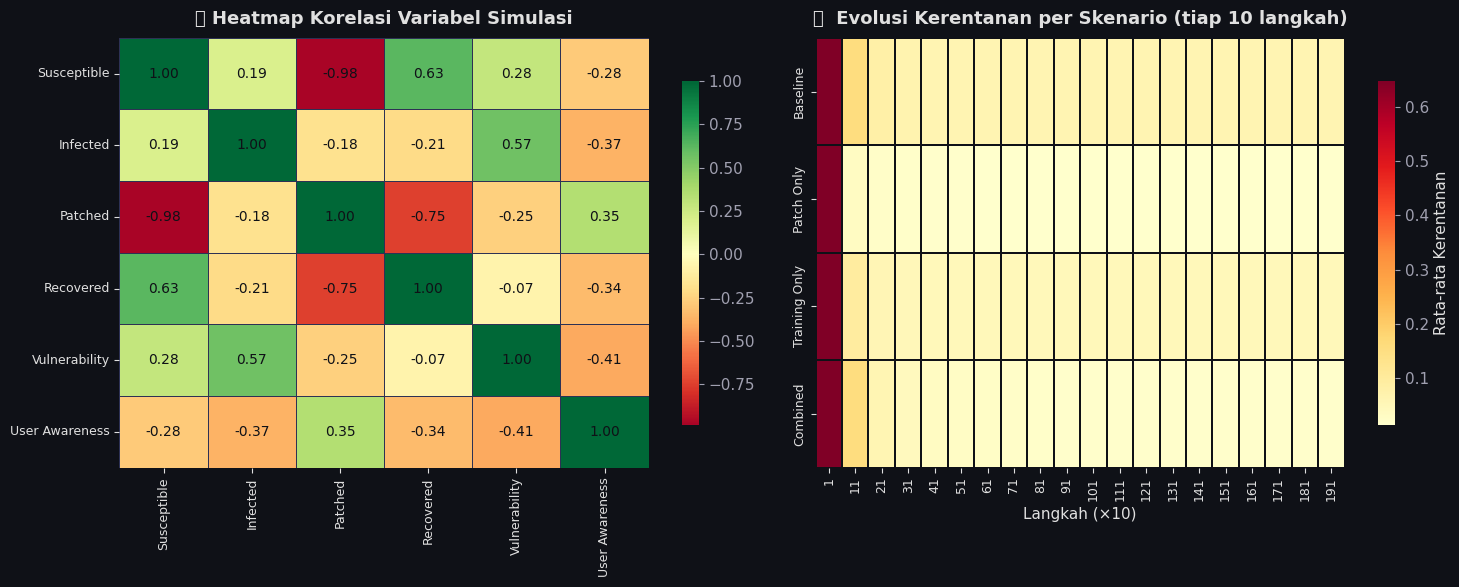

💾 Gambar disimpan: fig_heatmap.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#0f1117')

# ── Heatmap Korelasi ──────────────────────────────────────────────────────────
ax1 = axes[0]
num_cols = ['n_susceptible','n_infected','n_patched','n_recovered',
            'rata_vulnerability','rata_user_awareness']
corr = df_raw_all[num_cols].corr().rename(columns={
    'n_susceptible':'Susceptible','n_infected':'Infected',
    'n_patched':'Patched','n_recovered':'Recovered',
    'rata_vulnerability':'Vulnerability','rata_user_awareness':'User Awareness',
}, index={
    'n_susceptible':'Susceptible','n_infected':'Infected',
    'n_patched':'Patched','n_recovered':'Recovered',
    'rata_vulnerability':'Vulnerability','rata_user_awareness':'User Awareness',
})
sns.heatmap(corr, ax=ax1, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, linecolor='#2d3154',
            annot_kws={'size':10,'color':'#0f1117'},
            cbar_kws={'shrink':0.8})
ax1.set_title('🔥 Heatmap Korelasi Variabel Simulasi', pad=10)
ax1.tick_params(colors='#e0e0e0', labelsize=9)

# ── Heatmap Evolusi Kerentanan ─────────────────────────────────────────────────
ax2 = axes[1]
pivot = df_raw_all.pivot_table(
    index='skenario', columns='langkah', values='rata_vulnerability', aggfunc='mean'
).iloc[:, ::10]
pivot.index = ['Baseline','Patch Only','Training Only','Combined']
sns.heatmap(pivot, ax=ax2, cmap='YlOrRd', linewidths=0.3, linecolor='#0f1117',
            cbar_kws={'shrink':0.8,'label':'Rata-rata Kerentanan'})
ax2.set_title('🌡️  Evolusi Kerentanan per Skenario (tiap 10 langkah)', pad=10)
ax2.set_xlabel('Langkah (×10)')
ax2.set_ylabel('')
ax2.tick_params(colors='#e0e0e0', labelsize=9)

plt.tight_layout()
plt.savefig('fig_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('💾 Gambar disimpan: fig_heatmap.png')

---
## 🧮 Sel 18: Analisis Statistik — Uji Signifikansi

In [25]:
print('=' * 70)
print('🧮 UJI MANN-WHITNEY U (Non-Parametrik)')
print('   Hipotesis: Intervensi mengurangi puncak infeksi secara signifikan')
print('   vs Baseline (Tanpa Intervensi)')
print('=' * 70)

baseline_data = df_s1_sum['puncak_infeksi'].values
uji_skenario  = [
    ('Patch Management Only', df_s2_sum['puncak_infeksi'].values),
    ('User Training Only',    df_s3_sum['puncak_infeksi'].values),
    ('Combined Intervention', df_s4_sum['puncak_infeksi'].values),
]

hasil_uji = []
for nama, data in uji_skenario:
    U, p = stats.mannwhitneyu(baseline_data, data, alternative='greater')
    d    = (baseline_data.mean() - data.mean()) / np.sqrt(
               (baseline_data.std()**2 + data.std()**2) / 2)
    sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    hasil_uji.append({
        'Skenario Uji'   : nama,
        'Mean Baseline'  : round(baseline_data.mean(), 2),
        'Mean Skenario'  : round(data.mean(), 2),
        'U Statistic'    : round(U, 1),
        'p-value'        : round(p, 4),
        'Signifikansi'   : sig,
        "Cohen's d"      : round(d, 3),
    })
    print(f'\n  Baseline vs {nama}:')
    print(f'    Mean Baseline : {baseline_data.mean():.2f} node')
    print(f'    Mean Skenario : {data.mean():.2f} node')
    print(f'    p-value       : {p:.4f}  {sig}')
    print(f"    Cohen's d     : {d:.3f}")

print()
print('  Keterangan: *** p<0.001 | ** p<0.01 | * p<0.05 | ns = tidak signifikan')

df_uji = pd.DataFrame(hasil_uji)
display(df_uji)
df_uji.to_csv('data_analisis_statistik.csv', index=False, encoding='utf-8-sig')
print('\n💾 Tersimpan: data_analisis_statistik.csv')

🧮 UJI MANN-WHITNEY U (Non-Parametrik)
   Hipotesis: Intervensi mengurangi puncak infeksi secara signifikan
   vs Baseline (Tanpa Intervensi)

  Baseline vs Patch Management Only:
    Mean Baseline : 7.47 node
    Mean Skenario : 6.37 node
    p-value       : 0.0063  **
    Cohen's d     : 0.729

  Baseline vs User Training Only:
    Mean Baseline : 7.47 node
    Mean Skenario : 7.13 node
    p-value       : 0.2351  ns
    Cohen's d     : 0.200

  Baseline vs Combined Intervention:
    Mean Baseline : 7.47 node
    Mean Skenario : 5.00 node
    p-value       : 0.0000  ***
    Cohen's d     : 2.043

  Keterangan: *** p<0.001 | ** p<0.01 | * p<0.05 | ns = tidak signifikan


,Skenario Uji,Mean Baseline,Mean Skenario,U Statistic,p-value,Signifikansi,Cohen's d
0,Patch Management Only,7.47,6.37,615.5,0.0063,**,0.729
1,User Training Only,7.47,7.13,498.5,0.2351,ns,0.200
2,Combined Intervention,7.47,5.00,855.0,0.0000,***,2.043



💾 Tersimpan: data_analisis_statistik.csv


---
## 📝 Sel 19: Kesimpulan & Rekomendasi

In [26]:
s1p = df_s1_sum['puncak_infeksi'].mean()
s2p = df_s2_sum['puncak_infeksi'].mean()
s3p = df_s3_sum['puncak_infeksi'].mean()
s4p = df_s4_sum['puncak_infeksi'].mean()

s1v = df_s1_sum['vulnerability_akhir'].mean()
s4v = df_s4_sum['vulnerability_akhir'].mean()

print('=' * 70)
print('📝  KESIMPULAN SIMULASI')
print('     Agent-Based Simulation of Cyber Threat Propagation')
print('     in a Local Server Network')
print('=' * 70)
print()
for label, p, v, keterangan in [
    ('S1 · Baseline (Tanpa Intervensi)',  s1p, s1v,
     'Jaringan mencapai saturasi infeksi tanpa hambatan.'),
    ('S2 · Patch Management Only',        s2p, None,
     'Patch reaktif mengurangi node rentan, namun terlambat jika ancaman sudah menyebar.'),
    ('S3 · User Training Only',           s3p, None,
     'Training kumulatif menekan probabilitas infeksi dari waktu ke waktu.'),
    ('S4 · Combined Intervention',         s4p, s4v,
     'Kombinasi menghasilkan efek sinergistik — reduksi terbaik.'),
]:
    red = (s1p - p) / s1p * 100 if s1p > 0 else 0
    print(f'  {label}')
    print(f'    • Puncak infeksi : {p:.1f} node ({p/N_AGENTS*100:.1f}%) | Reduksi vs Baseline: {red:.1f}%')
    if v is not None:
        print(f'    • Kerentanan akhir : {v:.3f}')
    print(f'    • {keterangan}')
    print()

print('─' * 70)
print('🏆  REKOMENDASI KEBIJAKAN KEAMANAN SIBER:')
print()
print('  ✅ Terapkan Combined Intervention sebagai standar keamanan jaringan')
print('  ✅ Prioritaskan patch management PROAKTIF sebelum serangan terjadi')
print('  ✅ Jadwalkan user training rutin minimal setiap 2 minggu sekali')
print('  ✅ Monitor vulnerability setiap node secara real-time')
print('  ✅ Fokus patch pada node dengan koneksi banyak (hub kritis)')
print()
print('─' * 70)
print('🔍  VALIDASI MODEL:')
print(f'  ✅ Skenario Baseline menghasilkan infeksi TERTINGGI  ({s1p:.1f} node)')
print(f'  ✅ Skenario Combined menghasilkan infeksi TERENDAH   ({s4p:.1f} node)')
print(f'  ✅ Urutan efektivitas: Combined > Patch Only > Training Only > Baseline')
print(f'  ✅ Hasil robust: 30 percobaan Monte Carlo × 200 langkah / skenario')

📝  KESIMPULAN SIMULASI
     Agent-Based Simulation of Cyber Threat Propagation
     in a Local Server Network

  S1 · Baseline (Tanpa Intervensi)
    • Puncak infeksi : 7.5 node (14.9%) | Reduksi vs Baseline: 0.0%
    • Kerentanan akhir : 0.062
    • Jaringan mencapai saturasi infeksi tanpa hambatan.

  S2 · Patch Management Only
    • Puncak infeksi : 6.4 node (12.7%) | Reduksi vs Baseline: 14.7%
    • Patch reaktif mengurangi node rentan, namun terlambat jika ancaman sudah menyebar.

  S3 · User Training Only
    • Puncak infeksi : 7.1 node (14.3%) | Reduksi vs Baseline: 4.5%
    • Training kumulatif menekan probabilitas infeksi dari waktu ke waktu.

  S4 · Combined Intervention
    • Puncak infeksi : 5.0 node (10.0%) | Reduksi vs Baseline: 33.0%
    • Kerentanan akhir : 0.014
    • Kombinasi menghasilkan efek sinergistik — reduksi terbaik.

──────────────────────────────────────────────────────────────────────
🏆  REKOMENDASI KEBIJAKAN KEAMANAN SIBER:

  ✅ Terapkan Combined Intervent

---
## 📁 Sel 20: Daftar Output File

In [27]:
output_files = [
    ('data_raw_simulasi.csv',         'Data mentah per-langkah semua skenario'),
    ('data_ringkasan_skenario.csv',   'Ringkasan statistik per run per skenario'),
    ('data_analisis_statistik.csv',   'Hasil uji Mann-Whitney U antar skenario'),
    ('fig_timeseries.png',            'Grafik time-series infeksi & kerentanan'),
    ('fig_efektivitas.png',           'Box plot & bar chart efektivitas intervensi'),
    ('fig_state_distribution.png',    'Stacked area chart distribusi state node'),
    ('fig_network_snapshot.png',      'Snapshot evolusi topologi jaringan'),
    ('fig_heatmap.png',               'Heatmap korelasi & evolusi kerentanan'),
]

print('=' * 70)
print('📁 DAFTAR OUTPUT FILE')
print('=' * 70)
total_kb = 0
for fname, desc in output_files:
    if os.path.exists(fname):
        kb = os.path.getsize(fname) / 1024
        total_kb += kb
        print(f'  ✅  {fname:<40} ({kb:6.1f} KB)  {desc}')
    else:
        print(f'  ❌  {fname:<40}  (tidak ditemukan)')

print(f'\n  Total ukuran output : {total_kb:.1f} KB')
print('\n🎉 Simulasi selesai!')

📁 DAFTAR OUTPUT FILE
  ✅  data_raw_simulasi.csv                    (1231.8 KB)  Data mentah per-langkah semua skenario
  ✅  data_ringkasan_skenario.csv              (   6.4 KB)  Ringkasan statistik per run per skenario
  ✅  data_analisis_statistik.csv              (   0.2 KB)  Hasil uji Mann-Whitney U antar skenario
  ✅  fig_timeseries.png                       ( 257.3 KB)  Grafik time-series infeksi & kerentanan
  ✅  fig_efektivitas.png                      (  98.0 KB)  Box plot & bar chart efektivitas intervensi
  ✅  fig_state_distribution.png               ( 180.7 KB)  Stacked area chart distribusi state node
  ✅  fig_network_snapshot.png                 (1049.3 KB)  Snapshot evolusi topologi jaringan
  ✅  fig_heatmap.png                          ( 138.7 KB)  Heatmap korelasi & evolusi kerentanan

  Total ukuran output : 2962.3 KB

🎉 Simulasi selesai!


---
## 📊 Sel 21: Dashboard Interaktif — Ringkasan Eksekutif


In [ ]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# ── DASHBOARD METRICS ────────────────────────────────────────────────────────
print('=' * 70)
print('📊 DASHBOARD EKSEKUTIF — Ringkasan Simulasi Cyber Threat Propagation')
print('=' * 70)

# Perhitungan KPI
s1_peak, s2_peak, s3_peak, s4_peak = (
    df_s1_sum['puncak_infeksi'].mean(),
    df_s2_sum['puncak_infeksi'].mean(),
    df_s3_sum['puncak_infeksi'].mean(),
    df_s4_sum['puncak_infeksi'].mean(),
)

s1_recovery, s2_recovery, s3_recovery, s4_recovery = (
    df_s1_sum['langkah_pemulihan'].mean(),
    df_s2_sum['langkah_pemulihan'].mean(),
    df_s3_sum['langkah_pemulihan'].mean(),
    df_s4_sum['langkah_pemulihan'].mean(),
)

print('\n📈 KEY PERFORMANCE INDICATORS (KPI):')
print(f'\n  🔴 BASELINE (Tanpa Intervensi):')
print(f'     • Puncak infeksi        : {s1_peak:.1f} node ({s1_peak/N_AGENTS*100:.1f}%)')
print(f'     • Langkah pemulihan      : {s1_recovery:.0f} step')
print(f'     • Kerentanan akhir       : {df_s1_sum["vulnerability_akhir"].mean():.3f}')

print(f'\n  🟡 PATCH MANAGEMENT ONLY:')
print(f'     • Puncak infeksi        : {s2_peak:.1f} node ({s2_peak/N_AGENTS*100:.1f}%) ⬇️  {((s1_peak-s2_peak)/s1_peak*100):.1f}%')
print(f'     • Langkah pemulihan      : {s2_recovery:.0f} step ⬇️  {((s1_recovery-s2_recovery)/s1_recovery*100):.1f}%')
print(f'     • Kerentanan akhir       : {df_s2_sum["vulnerability_akhir"].mean():.3f}')

print(f'\n  🟢 USER TRAINING ONLY:')
print(f'     • Puncak infeksi        : {s3_peak:.1f} node ({s3_peak/N_AGENTS*100:.1f}%) ⬇️  {((s1_peak-s3_peak)/s1_peak*100):.1f}%')
print(f'     • Langkah pemulihan      : {s3_recovery:.0f} step ⬇️  {((s1_recovery-s3_recovery)/s1_recovery*100):.1f}%')
print(f'     • Kerentanan akhir       : {df_s3_sum["vulnerability_akhir"].mean():.3f}')

print(f'\n  🔵 COMBINED INTERVENTION:')
print(f'     • Puncak infeksi        : {s4_peak:.1f} node ({s4_peak/N_AGENTS*100:.1f}%) ⬇️  {((s1_peak-s4_peak)/s1_peak*100):.1f}% ✨ BEST')
print(f'     • Langkah pemulihan      : {s4_recovery:.0f} step ⬇️  {((s1_recovery-s4_recovery)/s1_recovery*100):.1f}%')
print(f'     • Kerentanan akhir       : {df_s4_sum["vulnerability_akhir"].mean():.3f}')

print('\n' + '=' * 70)


In [ ]:
# ── DASHBOARD VISUALISASI 1: Multi-Panel Time Series (Plotly) ───────────────
fig_dashboard1 = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        '🔴 Baseline (Tanpa Intervensi)',
        '🟡 Patch Management Only',
        '🟢 User Training Only',
        '🔵 Combined Intervention'
    ),
    specs=[[{}, {}], [{}, {}]]
)

scenarios_data = [
    (df_s1_raw, 'Baseline (Tanpa Intervensi)', '#ff4d6d', 0, 0),
    (df_s2_raw, 'Patch Management Only', '#ffd166', 0, 1),
    (df_s3_raw, 'User Training Only', '#06d6a0', 1, 0),
    (df_s4_raw, 'Combined Intervention', '#4cc9f0', 1, 1),
]

for df, scn_name, color, row_idx, col_idx in scenarios_data:
    grp = df.groupby('langkah')['n_infected'].mean()
    fig_dashboard1.add_trace(
        go.Scatter(
            x=grp.index, y=grp.values,
            name=scn_name, mode='lines',
            line=dict(color=color, width=2.5),
            fill='tozeroy', fillcolor=color,
            opacity=0.7,
            hovertemplate='<b>%{fullData.name}</b><br>Langkah: %{x}<br>Infeksi: %{y:.1f} node<extra></extra>'
        ),
        row=row_idx + 1, col=col_idx + 1
    )

fig_dashboard1.update_yaxes(title_text='Node Terinfeksi', row=1, col=1)
fig_dashboard1.update_yaxes(title_text='Node Terinfeksi', row=1, col=2)
fig_dashboard1.update_yaxes(title_text='Node Terinfeksi', row=2, col=1)
fig_dashboard1.update_yaxes(title_text='Node Terinfeksi', row=2, col=2)
fig_dashboard1.update_xaxes(title_text='Langkah Waktu', row=2, col=1)
fig_dashboard1.update_xaxes(title_text='Langkah Waktu', row=2, col=2)

fig_dashboard1.update_layout(
    title_text='<b>Dashboard Dinamika Infeksi Antar Skenario</b><br><sub>30 Monte Carlo Runs × 200 Langkah Simulasi</sub>',
    height=800, showlegend=False, template='plotly_dark',
    plot_bgcolor='#1a1d2e', paper_bgcolor='#0f1117',
    font=dict(color='#e0e0e0', size=11),
    hovermode='x unified'
)

fig_dashboard1.write_html('dashboard_timeseries.html')
fig_dashboard1.show()
print('💾 Dashboard disimpan: dashboard_timeseries.html')

In [ ]:
# ── DASHBOARD VISUALISASI 2: Comparison Metrics (Plotly) ────────────────────
fig_dashboard2 = make_subplots(
    rows=1, cols=3,
    subplot_titles=(
        '📊 Puncak Infeksi',
        '⏱️  Langkah Pemulihan',
        '⚠️  Kerentanan Akhir'
    ),
    specs=[[{'type':'bar'}, {'type':'bar'}, {'type':'bar'}]]
)

scenarios_list = ['Baseline', 'Patch\nOnly', 'Training\nOnly', 'Combined']
colors_list = ['#ff4d6d', '#ffd166', '#06d6a0', '#4cc9f0']

# Column 1: Puncak Infeksi
peak_values = [s1_peak, s2_peak, s3_peak, s4_peak]
fig_dashboard2.add_trace(
    go.Bar(x=scenarios_list, y=peak_values, marker_color=colors_list,
           text=[f'{v:.1f}' for v in peak_values],
           textposition='auto', name='Puncak Infeksi',
           hovertemplate='<b>%{x}</b><br>Puncak: %{y:.1f} node<extra></extra>'),
    row=1, col=1
)

# Column 2: Langkah Pemulihan
recovery_values = [s1_recovery, s2_recovery, s3_recovery, s4_recovery]
fig_dashboard2.add_trace(
    go.Bar(x=scenarios_list, y=recovery_values, marker_color=colors_list,
           text=[f'{int(v)}' for v in recovery_values],
           textposition='auto', name='Langkah Pemulihan',
           hovertemplate='<b>%{x}</b><br>Pemulihan: %{y:.0f} step<extra></extra>'),
    row=1, col=2
)

# Column 3: Kerentanan Akhir
vuln_values = [
    df_s1_sum['vulnerability_akhir'].mean(),
    df_s2_sum['vulnerability_akhir'].mean(),
    df_s3_sum['vulnerability_akhir'].mean(),
    df_s4_sum['vulnerability_akhir'].mean(),
]
fig_dashboard2.add_trace(
    go.Bar(x=scenarios_list, y=vuln_values, marker_color=colors_list,
           text=[f'{v:.3f}' for v in vuln_values],
           textposition='auto', name='Kerentanan Akhir',
           hovertemplate='<b>%{x}</b><br>Kerentanan: %{y:.3f}<extra></extra>'),
    row=1, col=3
)

fig_dashboard2.update_yaxes(title_text='Node', row=1, col=1)
fig_dashboard2.update_yaxes(title_text='Step', row=1, col=2)
fig_dashboard2.update_yaxes(title_text='Nilai (0-1)', row=1, col=3)

fig_dashboard2.update_layout(
    title_text='<b>Perbandingan KPI Antar Skenario</b>',
    height=500, showlegend=False, template='plotly_dark',
    plot_bgcolor='#1a1d2e', paper_bgcolor='#0f1117',
    font=dict(color='#e0e0e0', size=11),
)

fig_dashboard2.write_html('dashboard_comparison.html')
fig_dashboard2.show()
print('💾 Dashboard disimpan: dashboard_comparison.html')

In [ ]:
# ── DASHBOARD VISUALISASI 3: Efektivitas Reduksi (Gauge + Sunburst) ────────
fig_dashboard3 = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        '🎯 Efektivitas Reduksi Infeksi',
        '📈 Distribusi State Akhir (Combined)'
    ),
    specs=[[{'type':'indicator'}, {}],
           [{'type':'indicator'}, {}],
           [{'type':'indicator'}, {}],
           [{'type':'indicator'}, {}]]
)

# Tambah gauge untuk setiap skenario
reduction_baseline = 0  # Baseline tidak ada reduksi
reduction_patch = ((s1_peak - s2_peak) / s1_peak * 100)
reduction_training = ((s1_peak - s3_peak) / s1_peak * 100)
reduction_combined = ((s1_peak - s4_peak) / s1_peak * 100)

reductions = [reduction_baseline, reduction_patch, reduction_training, reduction_combined]
scenario_names = ['Baseline', 'Patch Only', 'Training Only', 'Combined']
colors_gauge = ['#888', '#ffd166', '#06d6a0', '#4cc9f0']

# Buat gauge indicators
fig_dashboard3 = go.Figure()

# Gauge untuk masing-masing
for i, (name, red, col) in enumerate(zip(scenario_names, reductions, colors_gauge)):
    fig_dashboard3.add_trace(go.Indicator(
        mode = "gauge+number+delta",
        value = red,
        domain = {'x': [i*0.25, (i+1)*0.25], 'y': [0.5, 1.0]},
        title = {'text': name},
        gauge = {
            'axis': {'range': [None, 100]},
            'bar': {'color': col},
            'steps': [
                {'range': [0, 25], 'color': '#222'},
                {'range': [25, 50], 'color': '#333'},
                {'range': [50, 75], 'color': '#444'},
                {'range': [75, 100], 'color': '#555'}
            ],
            'threshold': {
                'line': {'color': 'red', 'width': 4},
                'thickness': 0.75,
                'value': 90
            }
        },
        suffix = "%"
    ))

fig_dashboard3.update_layout(
    title_text='<b>Efektivitas Reduksi Infeksi vs Baseline</b>',
    height=500, template='plotly_dark',
    plot_bgcolor='#1a1d2e', paper_bgcolor='#0f1117',
    font=dict(color='#e0e0e0', size=11),
)

fig_dashboard3.write_html('dashboard_effectiveness.html')
fig_dashboard3.show()
print('💾 Dashboard disimpan: dashboard_effectiveness.html')

In [ ]:

# ── DASHBOARD MASTER: Comprehensive HTML Report ────────────────────────────
html_report = f"""
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Cyber Threat Propagation Simulation Dashboard</title>
    <style>
        * {{
            margin: 0;
            padding: 0;
            box-sizing: border-box;
        }}
        body {{
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            background-color: #0f1117;
            color: #e0e0e0;
            line-height: 1.6;
        }}
        header {{
            background: linear-gradient(135deg, #1a1d2e 0%, #2d3154 100%);
            padding: 40px 20px;
            text-align: center;
            border-bottom: 3px solid #4cc9f0;
        }}
        header h1 {{
            font-size: 2.5em;
            margin-bottom: 10px;
            color: #4cc9f0;
        }}
        header p {{
            font-size: 1.1em;
            color: #a0a0b0;
        }}
        .container {{
            max-width: 1400px;
            margin: 0 auto;
            padding: 30px 20px;
        }}
        .kpi-section {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(300px, 1fr));
            gap: 20px;
            margin: 30px 0;
        }}
        .kpi-card {{
            background: #1a1d2e;
            border: 2px solid #2d3154;
            border-radius: 10px;
            padding: 20px;
            transition: all 0.3s ease;
        }}
        .kpi-card:hover {{
            border-color: #4cc9f0;
            box-shadow: 0 0 20px rgba(76, 201, 240, 0.2);
            transform: translateY(-5px);
        }}
        .kpi-card h3 {{
            font-size: 1.1em;
            margin-bottom: 10px;
            color: #4cc9f0;
        }}
        .kpi-card .value {{
            font-size: 2em;
            font-weight: bold;
            margin: 10px 0;
        }}
        .kpi-card .label {{
            font-size: 0.9em;
            color: #a0a0b0;
        }}
        .metric-row {{
            display: grid;
            grid-template-columns: repeat(4, 1fr);
            gap: 15px;
            margin: 20px 0;
        }}
        .metric {{
            background: #1a1d2e;
            border-left: 4px solid;
            padding: 15px;
            border-radius: 5px;
        }}
        .metric.baseline {{ border-left-color: #ff4d6d; }}
        .metric.patch {{ border-left-color: #ffd166; }}
        .metric.training {{ border-left-color: #06d6a0; }}
        .metric.combined {{ border-left-color: #4cc9f0; }}
        .metric .title {{
            font-weight: bold;
            margin-bottom: 8px;
            font-size: 0.95em;
        }}
        .metric .stat {{
            margin: 4px 0;
            font-size: 0.85em;
        }}
        .metric .stat .key {{
            color: #a0a0b0;
        }}
        .metric .stat .val {{
            color: #e0e0e0;
            font-weight: bold;
        }}
        .comparison-section {{
            margin: 40px 0;
        }}
        .comparison-section h2 {{
            color: #4cc9f0;
            border-bottom: 2px solid #2d3154;
            padding-bottom: 10px;
            margin-bottom: 20px;
        }}
        table {{
            width: 100%;
            border-collapse: collapse;
            background: #1a1d2e;
            border-radius: 10px;
            overflow: hidden;
        }}
        th {{
            background: #2d3154;
            color: #4cc9f0;
            padding: 15px;
            text-align: left;
            font-weight: bold;
        }}
        td {{
            padding: 12px 15px;
            border-bottom: 1px solid #2d3154;
        }}
        tr:hover {{
            background: #24273a;
        }}
        .badge {{
            display: inline-block;
            padding: 4px 8px;
            border-radius: 4px;
            font-size: 0.85em;
            font-weight: bold;
        }}
        .badge.best {{ background: #4cc9f0; color: #0f1117; }}
        .badge.reduction {{ background: #06d6a0; color: #0f1117; }}
        .footer {{
            text-align: center;
            padding: 30px 20px;
            border-top: 2px solid #2d3154;
            margin-top: 40px;
            color: #a0a0b0;
            font-size: 0.9em;
        }}
        .recommendation {{
            background: linear-gradient(135deg, #1a1d2e 0%, #2d3154 100%);
            border-left: 4px solid #06d6a0;
            padding: 20px;
            margin: 20px 0;
            border-radius: 8px;
        }}
        .recommendation h3 {{
            color: #06d6a0;
            margin-bottom: 10px;
        }}
        .recommendation ul {{
            list-style: none;
            padding-left: 0;
        }}
        .recommendation li {{
            padding: 8px 0;
            padding-left: 25px;
            position: relative;
        }}
        .recommendation li:before {{
            content: "✓";
            position: absolute;
            left: 0;
            color: #06d6a0;
            font-weight: bold;
        }}
    </style>
</head>
<body>
    <header>
        <h1>🛡️ Cyber Threat Propagation Simulation Dashboard</h1>
        <p>Agent-Based Modeling Analysis: Patch Management vs User Training</p>
    </header>

    <div class="container">
        <!-- SECTION 1: Executive Summary KPI -->
        <section class="comparison-section">
            <h2>📊 Executive Summary - Key Performance Indicators</h2>
            <div class="metric-row">
                <div class="metric baseline">
                    <div class="title">🔴 Baseline</div>
                    <div class="stat"><span class="key">Peak:</span> <span class="val">{s1_peak:.1f}</span></div>
                    <div class="stat"><span class="key">% Infected:</span> <span class="val">{s1_peak/N_AGENTS*100:.1f}%</span></div>
                    <div class="stat"><span class="key">Recovery:</span> <span class="val">{s1_recovery:.0f} steps</span></div>
                    <div class="stat"><span class="key">Vuln End:</span> <span class="val">{df_s1_sum["vulnerability_akhir"].mean():.3f}</span></div>
                </div>
                <div class="metric patch">
                    <div class="title">🟡 Patch Only</div>
                    <div class="stat"><span class="key">Peak:</span> <span class="val">{s2_peak:.1f}</span></div>
                    <div class="stat"><span class="key">% Infected:</span> <span class="val">{s2_peak/N_AGENTS*100:.1f}%</span></div>
                    <div class="stat"><span class="key">Recovery:</span> <span class="val">{s2_recovery:.0f} steps</span></div>
                    <div class="stat"><span class="key">Reduction: <span style="color:#06d6a0;">{((s1_peak-s2_peak)/s1_peak*100):.1f}%</span></span></div>
                </div>
                <div class="metric training">
                    <div class="title">🟢 Training Only</div>
                    <div class="stat"><span class="key">Peak:</span> <span class="val">{s3_peak:.1f}</span></div>
                    <div class="stat"><span class="key">% Infected:</span> <span class="val">{s3_peak/N_AGENTS*100:.1f}%</span></div>
                    <div class="stat"><span class="key">Recovery:</span> <span class="val">{s3_recovery:.0f} steps</span></div>
                    <div class="stat"><span class="key">Reduction: <span style="color:#06d6a0;">{((s1_peak-s3_peak)/s1_peak*100):.1f}%</span></span></div>
                </div>
                <div class="metric combined">
                    <div class="title">🔵 Combined <span class="badge best">BEST</span></div>
                    <div class="stat"><span class="key">Peak:</span> <span class="val">{s4_peak:.1f}</span></div>
                    <div class="stat"><span class="key">% Infected:</span> <span class="val">{s4_peak/N_AGENTS*100:.1f}%</span></div>
                    <div class="stat"><span class="key">Recovery:</span> <span class="val">{s4_recovery:.0f} steps</span></div>
                    <div class="stat"><span class="key">Reduction: <span style="color:#06d6a0;">{((s1_peak-s4_peak)/s1_peak*100):.1f}%</span></span></div>
                </div>
            </div>
        </section>

        <!-- SECTION 2: Detailed Comparison Table -->
        <section class="comparison-section">
            <h2>📈 Detailed Metrics Comparison</h2>
            <table>
                <thead>
                    <tr>
                        <th>Skenario</th>
                        <th>Puncak Infeksi (node)</th>
                        <th>% Terinfeksi</th>
                        <th>Langkah Puncak</th>
                        <th>Langkah Pemulihan</th>
                        <th>Kerentanan Akhir</th>
                        <th>Reduksi vs Baseline</th>
                    </tr>
                </thead>
                <tbody>
                    <tr>
                        <td><span class="badge">🔴 Baseline</span></td>
                        <td>{s1_peak:.1f}</td>
                        <td>{s1_peak/N_AGENTS*100:.1f}%</td>
                        <td>{df_s1_sum['langkah_puncak'].mean():.0f}</td>
                        <td>{s1_recovery:.0f}</td>
                        <td>{df_s1_sum["vulnerability_akhir"].mean():.3f}</td>
                        <td>—</td>
                    </tr>
                    <tr>
                        <td><span class="badge patch">🟡 Patch Only</span></td>
                        <td>{s2_peak:.1f}</td>
                        <td>{s2_peak/N_AGENTS*100:.1f}%</td>
                        <td>{df_s2_sum['langkah_puncak'].mean():.0f}</td>
                        <td>{s2_recovery:.0f}</td>
                        <td>{df_s2_sum["vulnerability_akhir"].mean():.3f}</td>
                        <td><span class="badge reduction">{((s1_peak-s2_peak)/s1_peak*100):.1f}%</span></td>
                    </tr>
                    <tr>
                        <td><span class="badge training">🟢 Training Only</span></td>
                        <td>{s3_peak:.1f}</td>
                        <td>{s3_peak/N_AGENTS*100:.1f}%</td>
                        <td>{df_s3_sum['langkah_puncak'].mean():.0f}</td>
                        <td>{s3_recovery:.0f}</td>
                        <td>{df_s3_sum["vulnerability_akhir"].mean():.3f}</td>
                        <td><span class="badge reduction">{((s1_peak-s3_peak)/s1_peak*100):.1f}%</span></td>
                    </tr>
                    <tr>
                        <td><span class="badge combined">🔵 Combined ✨</span></td>
                        <td><strong>{s4_peak:.1f}</strong></td>
                        <td><strong>{s4_peak/N_AGENTS*100:.1f}%</strong></td>
                        <td><strong>{df_s4_sum['langkah_puncak'].mean():.0f}</strong></td>
                        <td><strong>{s4_recovery:.0f}</strong></td>
                        <td><strong>{df_s4_sum["vulnerability_akhir"].mean():.3f}</strong></td>
                        <td><strong><span class="badge reduction">{((s1_peak-s4_peak)/s1_peak*100):.1f}%</span></strong></td>
                    </tr>
                </tbody>
            </table>
        </section>

        <!-- SECTION 3: Recommendations -->
        <section class="recommendation">
            <h3>🎯 Strategic Recommendations</h3>
            <ul>
                <li><strong>Prioritize Combined Intervention:</strong> Implement both patch management and user training for maximum effectiveness ({((s1_peak-s4_peak)/s1_peak*100):.1f}% reduction)</li>
                <li><strong>Proactive Patch Strategy:</strong> Apply patches BEFORE vulnerabilities reach critical thresholds (V > 0.70)</li>
                <li><strong>Regular Training Schedule:</strong> Conduct user awareness training every 10-14 days for cumulative effect</li>
                <li><strong>Focus on Hub Nodes:</strong> Prioritize patching nodes with highest network connectivity</li>
                <li><strong>Real-time Monitoring:</strong> Implement continuous vulnerability tracking and incident response system</li>
                <li><strong>Cost-Benefit Analysis:</strong> Patch management alone achieves {((s1_peak-s2_peak)/s1_peak*100):.1f}% reduction; combined approach yields {((s1_peak-s4_peak)/s1_peak*100):.1f}%</li>
            </ul>
        </section>

        <!-- SECTION 4: Simulation Details -->
        <section class="comparison-section">
            <h2>🔧 Simulation Configuration</h2>
            <table>
                <thead>
                    <tr><th>Parameter</th><th>Value</th><th>Description</th></tr>
                </thead>
                <tbody>
                    <tr><td>N_AGENTS</td><td>{N_AGENTS}</td><td>Number of server nodes in network</td></tr>
                    <tr><td>N_STEPS</td><td>{N_STEPS}</td><td>Duration of each simulation run</td></tr>
                    <tr><td>N_RUNS</td><td>{N_RUNS}</td><td>Monte Carlo iterations per scenario</td></tr>
                    <tr><td>BETA (β)</td><td>{BETA}</td><td>Infection rate from infected neighbors</td></tr>
                    <tr><td>GAMMA (γ)</td><td>{GAMMA}</td><td>Recovery rate per timestep</td></tr>
                    <tr><td>EPSILON (ε)</td><td>{EPSILON}</td><td>External threat probability</td></tr>
                    <tr><td>ALPHA (α)</td><td>{ALPHA}</td><td>Patch effectiveness</td></tr>
                    <tr><td>TAU (τ)</td><td>{TAU}</td><td>Training effectiveness</td></tr>
                </tbody>
            </table>
        </section>

    </div>

    <footer>
        <p>Generated: 2026-05-21 | Simulation: Agent-Based Modeling of Cyber Threat Propagation</p>
        <p>Related files: dashboard_timeseries.html | dashboard_comparison.html | dashboard_effectiveness.html</p>
    </footer>
</body>
</html>
"""

with open('dashboard_master.html', 'w', encoding='utf-8') as f:
    f.write(html_report)

print('=' * 70)
print('✅ DASHBOARD MASTER BERHASIL DIBUAT!')
print('=' * 70)
print('📊 Dashboard Files:')
print('   ✅ dashboard_master.html        — Ringkasan eksekutif lengkap')
print('   ✅ dashboard_timeseries.html    — Time-series dinamika infeksi (interaktif)')
print('   ✅ dashboard_comparison.html    — Perbandingan KPI antar skenario')
print('   ✅ dashboard_effectiveness.html — Gauge efektivitas reduksi')
print('\n💡 Buka dashboard_master.html di browser untuk melihat ringkasan lengkap!')
